In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import zscore

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("data/processed/delhi_hourly_aqi.csv")

print(df.shape)

df.head()

(122752, 25)


,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe


In [3]:
missing = (df.isnull().sum()/len(df))*100


missing = missing.sort_values(ascending=False)


print(missing)

datetime        0.0
date            0.0
year            0.0
month           0.0
day             0.0
hour            0.0
day_of_week     0.0
is_weekend      0.0
season          0.0
city            0.0
station         0.0
latitude        0.0
longitude       0.0
pm25            0.0
pm10            0.0
no2             0.0
so2             0.0
co              0.0
o3              0.0
temperature     0.0
humidity        0.0
wind_speed      0.0
visibility      0.0
aqi             0.0
aqi_category    0.0
dtype: float64


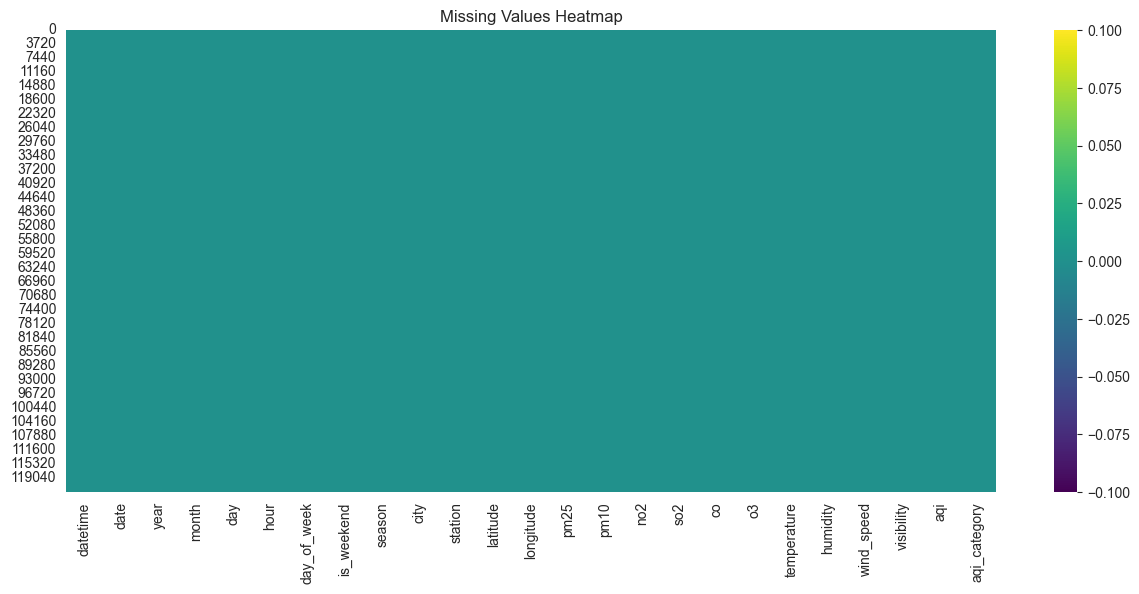

In [4]:
plt.figure(figsize=(15,6))

sns.heatmap(df.isnull(),

            cbar=True,

            cmap='viridis')


plt.title("Missing Values Heatmap")


plt.show()

In [6]:
num_cols = [

'pm25',
'pm10',
'no2',
'so2',
'co',
'o3'

]


for col in num_cols:

    df[col]=df[col].fillna(df[col].median())



weather = [

'temperature',

'humidity',

'wind_speed'

]


for col in weather:

    df[col]=df[col].fillna(df[col].mean())



df['visibility'] = df['visibility'].ffill()

df['aqi'] = df['aqi'].ffill()

Done
0


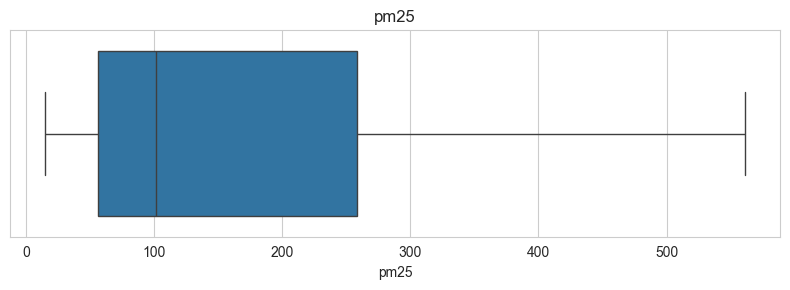

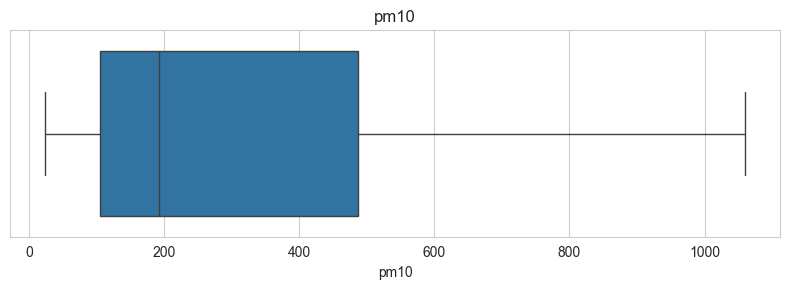

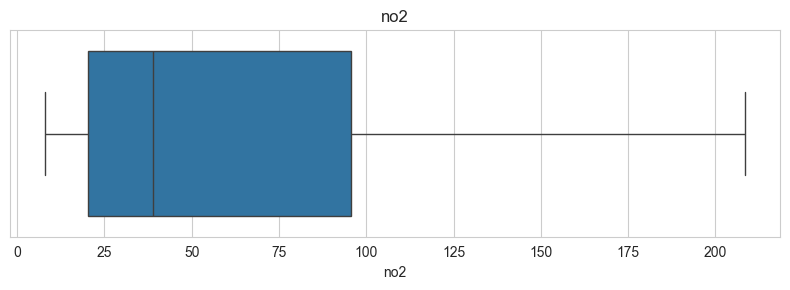

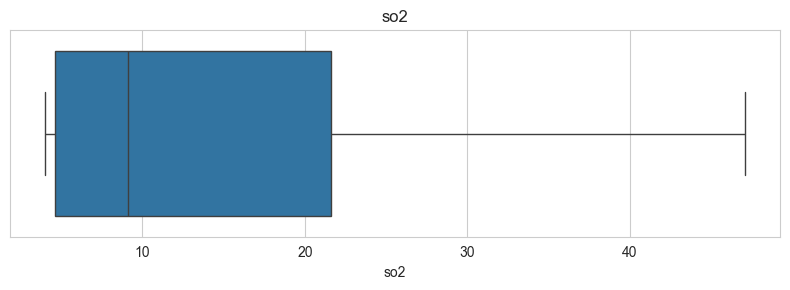

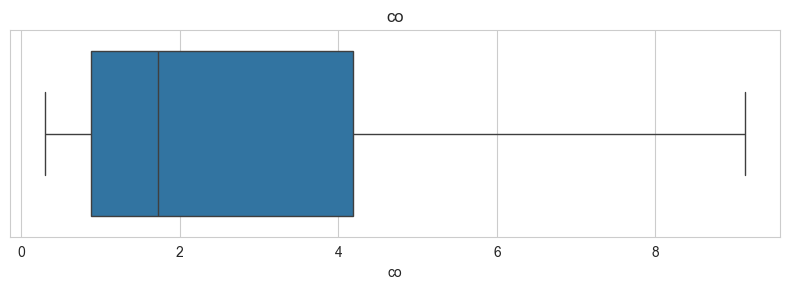

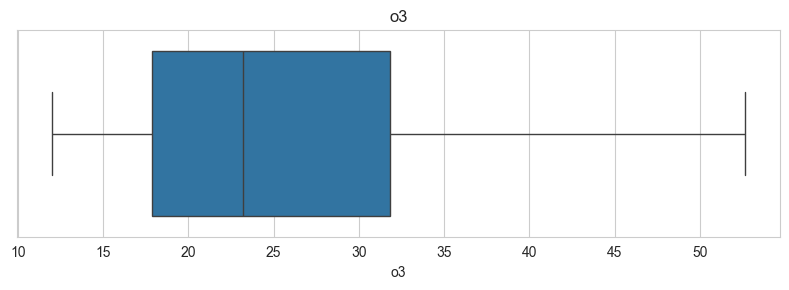

In [10]:
cols=[

'pm25',
'pm10',
'no2',
'so2',
'co',
'o3'

]


for col in cols:


    Q1=df[col].quantile(0.25)

    Q3=df[col].quantile(0.75)

    IQR=Q3-Q1


    lower=Q1-1.5*IQR

    upper=Q3+1.5*IQR


    df[col]=np.where(

        df[col]>upper,

        upper,

        df[col]

    )


    df[col]=np.where(

        df[col]<lower,

        lower,

        df[col]

    )


print("Done")

z=np.abs(zscore(df[cols]))

outliers=(z>3)


print(outliers.sum())

for col in cols:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[col])

    plt.title(col)
    plt.tight_layout()
    plt.show()

In [15]:
df['datetime'] = pd.to_datetime(df['datetime'])

monthly = (
    df.resample(
        'ME',
        on='datetime'
    )['aqi']
    .mean()
    .reset_index()
)
fig = px.line(

monthly,

x='datetime',

y='aqi',

title='Monthly Average AQI'

)

fig.show()

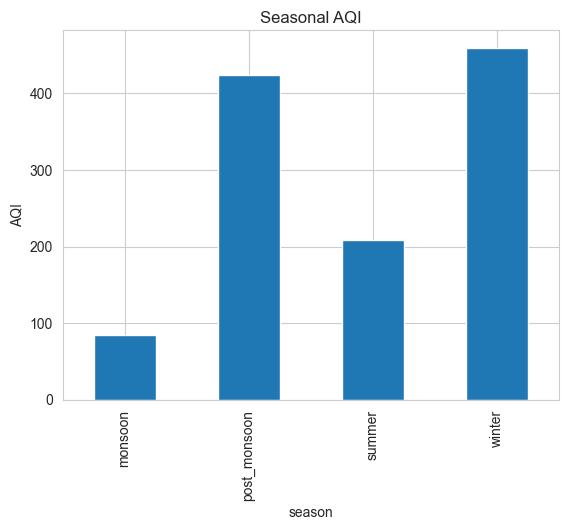

In [16]:
seasonal = df.groupby(

'season'

)['aqi'].mean()


seasonal.plot(

kind='bar'

)


plt.ylabel("AQI")

plt.title(

"Seasonal AQI"

)

plt.show()

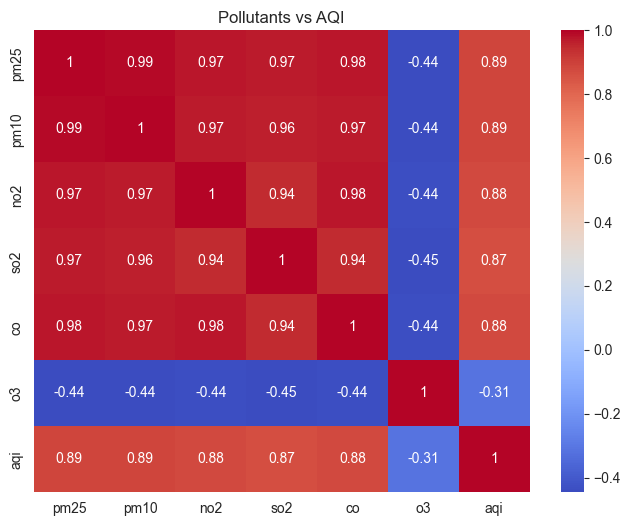

In [17]:
pollutants=[

'pm25',
'pm10',
'no2',
'so2',
'co',
'o3',
'aqi'

]


corr=df[pollutants].corr()


plt.figure(figsize=(8,6))

sns.heatmap(

corr,

annot=True,

cmap='coolwarm'

)


plt.title(

"Pollutants vs AQI"

)

plt.show()

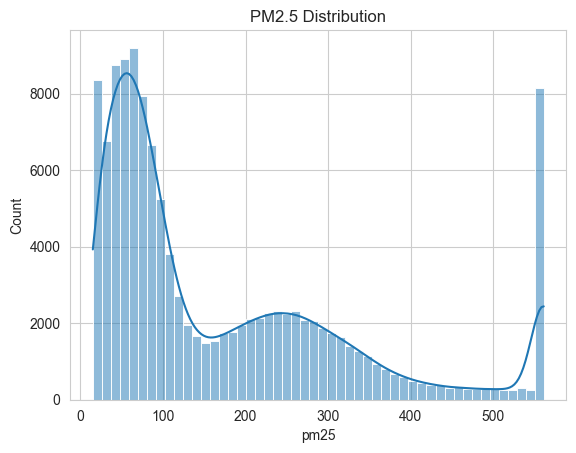

In [18]:
sns.histplot(

df['pm25'],

kde=True,

bins=50

)


plt.title(

"PM2.5 Distribution"

)

plt.show()

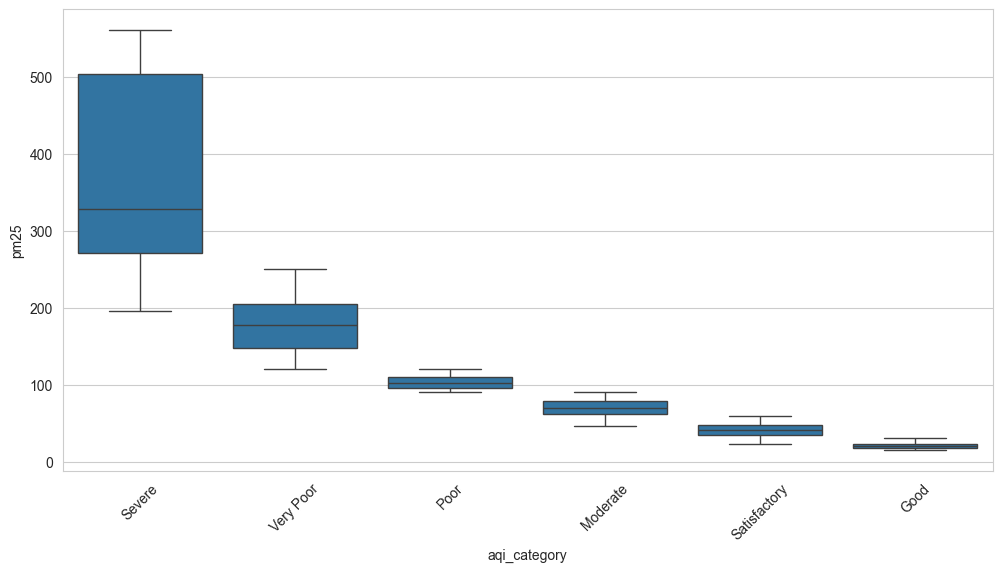

In [19]:
plt.figure(

figsize=(12,6)

)


sns.boxplot(

x='aqi_category',

y='pm25',

data=df

)



plt.xticks(

rotation=45

)


plt.show()

In [21]:
df.to_csv(

"data/processed/delhi_cleaned.csv",

index=False

)


print(

"Dataset Saved"

)

Dataset Saved
